In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("nyc_tlc_cleaned.csv")

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,PU_Borough,DO_Borough,trip_duration,pickup_hour,pickup_weekday,pickup_month,pickup_day,is_weekend
0,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,0,1,13.0,0.0,...,0.3,16.56,Manhattan,Manhattan,844.0,8,5,3,25,1
1,1,2017-04-11 14:53:00,2017-04-11 15:19:00,1,1.80,1,0,1,16.0,0.0,...,0.3,20.80,Manhattan,Manhattan,1560.0,14,1,4,11,0
2,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,0,1,6.5,0.0,...,0.3,8.75,Manhattan,Manhattan,432.0,7,4,12,15,0
3,2,2017-05-07 13:17:00,2017-05-07 13:48:00,1,3.70,1,0,1,20.5,0.0,...,0.3,27.69,Brooklyn,Brooklyn,1860.0,13,6,5,7,1
4,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,0,2,16.5,0.5,...,0.3,17.80,Manhattan,Brooklyn,1003.0,23,5,4,15,1


<Axes: title={'center': 'Fare Amount Distribution'}, xlabel='amount in dollars', ylabel='Frequency of trips'>

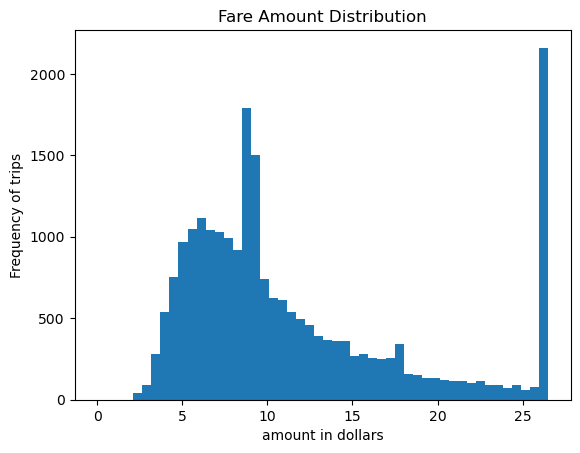

In [3]:
df['fare_amount'].plot(kind='hist', bins=50, title='Fare Amount Distribution',xlabel='amount in dollars',ylabel='Frequency of trips')

Insight:
Fare amounts are right-skewed, with majority of trips falling in lower fare ranges. High fare values represent long-distance or special-rate trips

<Axes: title={'center': 'Trip Distance Distribution'}, xlabel='distance in miles', ylabel='Frequency of trips'>

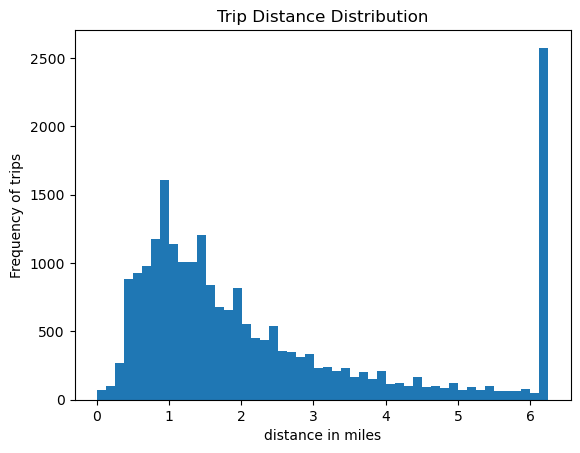

In [4]:
df['trip_distance'].plot(kind='hist', bins=50, title='Trip Distance Distribution',xlabel='distance in miles',ylabel='Frequency of trips')

Insight:
Most taxi trips are short-distance rides (primarily within 1–3 miles), indicating dominance of intra-city travel. Long-distance trips are rare and represent outliers.
    Insight

Most taxi trips are short to medium distances, indicating that taxis are commonly used for quick urban transportation rather than long-distance travel.

<Axes: title={'center': 'Trip Duration Distribution'}, xlabel='seconds', ylabel='Frequency of trips'>

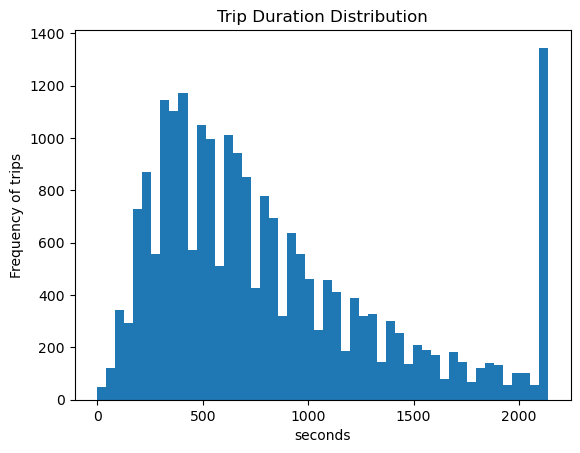

In [5]:
df['trip_duration'].plot(kind='hist', bins=50, title='Trip Duration Distribution',xlabel='seconds',ylabel='Frequency of trips')

Insight:
Trip duration shows positive skewness, where most trips are short in time. Extremely long durations likely correspond to traffic delays or special trips

<Axes: title={'center': 'Trips by Hour'}, xlabel='pickup_hour', ylabel='Frequency of trips'>

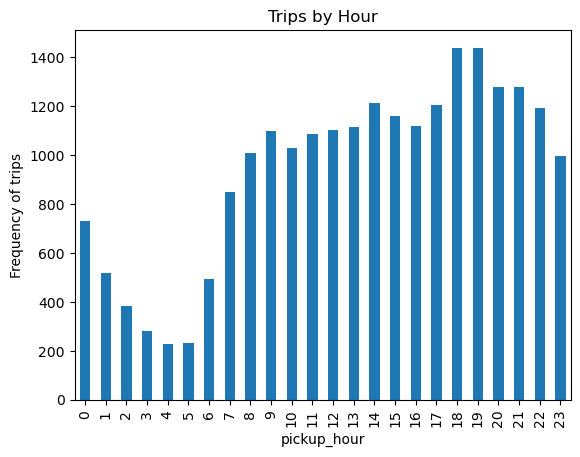

In [6]:
df['pickup_hour'].value_counts().sort_index().plot(kind='bar', title='Trips by Hour',ylabel='Frequency of trips')

Insight:
Trip demand peaks during morning and evening hours, reflecting work commute patterns. Late-night demand is comparatively lower but still present.
    12am to 11pm

<Axes: title={'center': 'Trips by Weekday'}, xlabel='pickup_weekday', ylabel='Frequency of trips'>

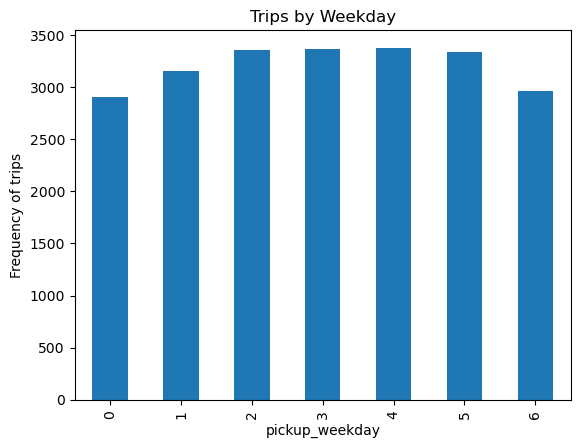

In [7]:
df['pickup_weekday'].value_counts().sort_index().plot(kind='bar', title='Trips by Weekday',ylabel='Frequency of trips')

Insight:
Weekday trips are higher than weekends, indicating strong commuter-based taxi usage. sunday to saturday

<Axes: title={'center': 'Payment Type Distribution'}, xlabel='payment_type', ylabel='Frequency of trips'>

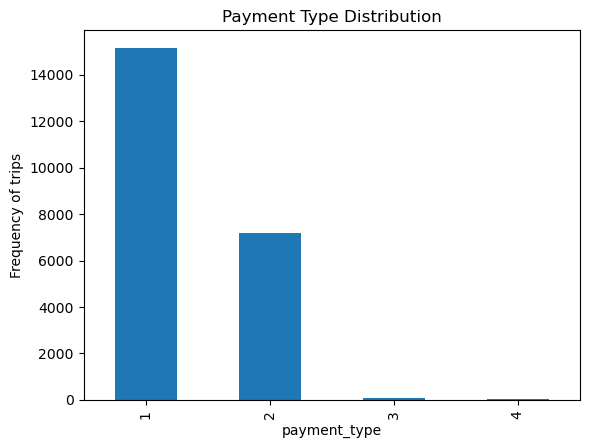

In [8]:
df['payment_type'].value_counts().plot(kind='bar', title='Payment Type Distribution',ylabel='Frequency of trips')

Insight:
Credit card transactions dominate over cash payments, showing increasing digital payment adoption in urban transportation.

<Axes: title={'center': 'Passenger Count Distribution'}, xlabel='passenger_count', ylabel='Number of Trips'>

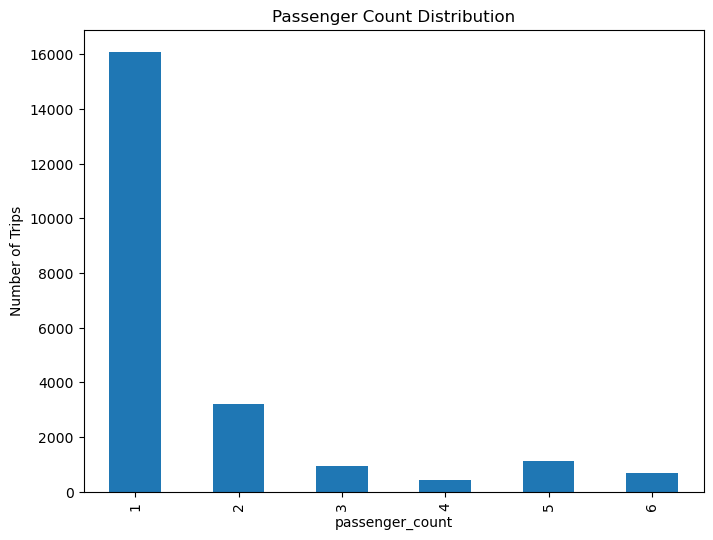

In [9]:
df['passenger_count'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(8,6),
    title="Passenger Count Distribution",
    ylabel="Number of Trips"
)

Insight

Most taxi trips involve a small number of passengers, typically one or two riders. This indicates that taxis are primarily used for individual or small group transportation rather than large groups.

<Axes: title={'center': 'Avg Revenue by Pickup Borough'}, xlabel='PU_Borough', ylabel='Revenue in dollars'>

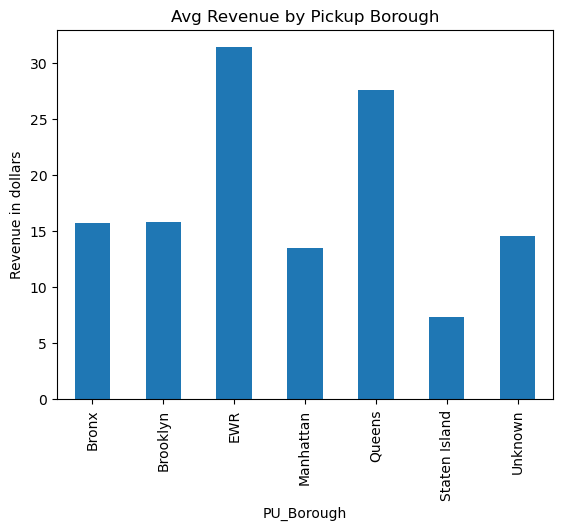

In [10]:
df.groupby('PU_Borough')['total_amount'].mean().plot(kind='bar', title='Avg Revenue by Pickup Borough',ylabel='Revenue in dollars')

Insight

Some boroughs generate higher average revenue per trip than others. This may be due to longer travel distances, higher demand areas, or trips originating from airports or business districts.

<Axes: title={'center': 'Payment Share'}, ylabel='count in %'>

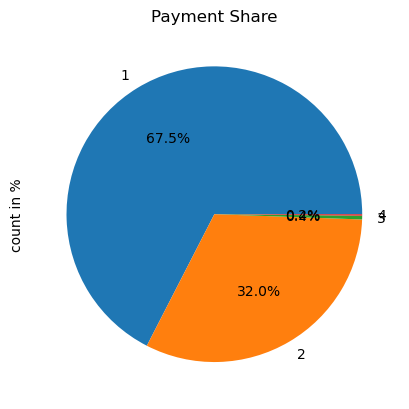

In [11]:
df['payment_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Payment Share',ylabel='count in %')

Insight:
Certain boroughs (typically EWR) show higher average revenue per trip, indicating higher fare density and premium zones.

Insight:
The majority share belongs to electronic payments, suggesting structured billing and transparency in taxi services.

Insight:
Standard rate codes dominate, while special rates (airport, negotiated fares) form a smaller proportion.

<Axes: title={'center': 'Hourly Trip Trend'}, xlabel='pickup_hour', ylabel='Frequency of trips'>

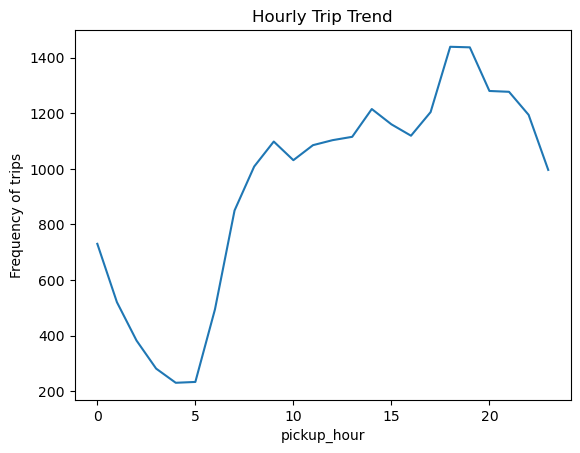

In [12]:
df['pickup_hour'].value_counts().sort_index().plot(kind='line', title='Hourly Trip Trend',ylabel='Frequency of trips')

Insight:
Demand fluctuates across the day with visible peaks during commute hours and gradual reduction post midnight.

<Axes: title={'center': 'Avg Fare by Hour'}, xlabel='pickup_hour', ylabel='Fare in $'>

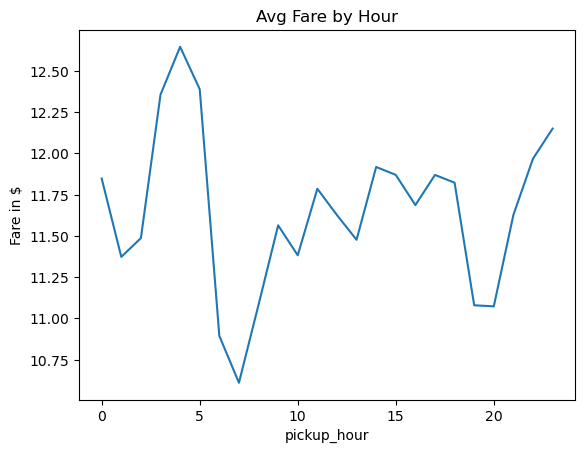

In [13]:
df.groupby('pickup_hour')['fare_amount'].mean().plot(kind='line', title='Avg Fare by Hour',ylabel='Fare in $')

Insight:
Average fare increases during late-night or peak hours, possibly due to traffic congestion or surge pricing.

<Axes: title={'center': 'Monthly Revenue Trend'}, xlabel='pickup_month', ylabel='Revenue in $'>

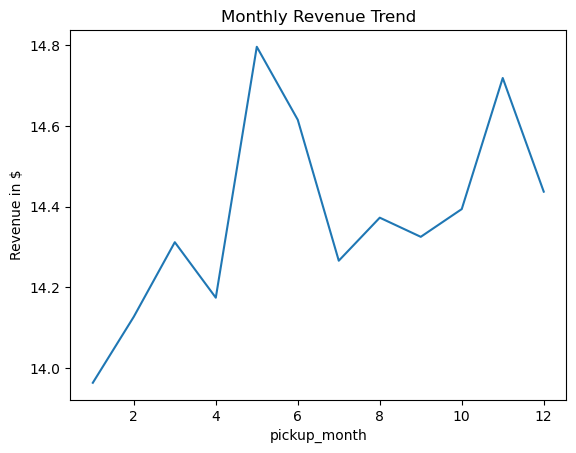

In [14]:
df.groupby('pickup_month')['total_amount'].mean().plot(kind='line', title='Monthly Revenue Trend',ylabel='Revenue in $')

Insight:
Monthly trend reflects seasonal demand variations, potentially influenced by tourism or weather conditions

<Axes: title={'center': 'Hourly Demand Area'}, xlabel='pickup_hour', ylabel='Trips'>

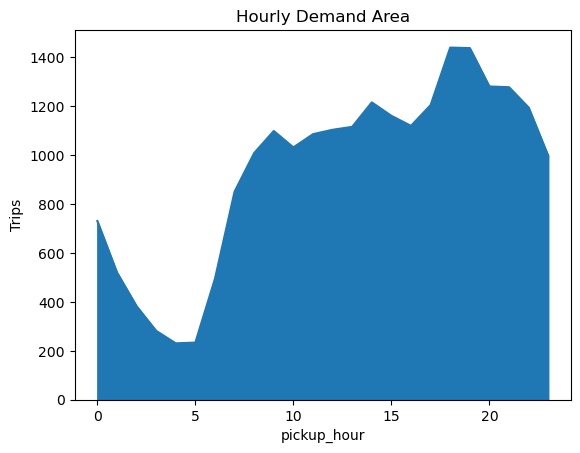

In [15]:
df['pickup_hour'].value_counts().sort_index().plot(kind='area', title='Hourly Demand Area',ylabel='Trips')

Insight:
The area plot emphasizes cumulative demand growth during active hours, visually highlighting peak taxi activity periods.

<Axes: title={'center': 'Total Revenue Area'}, xlabel='PU_Borough', ylabel='Revenue in $'>

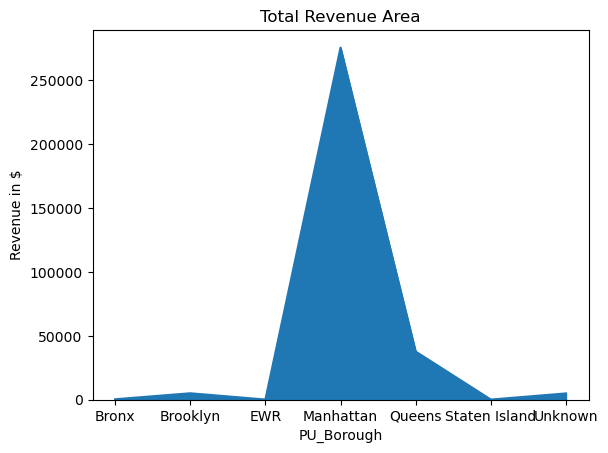

In [16]:
df.groupby('PU_Borough')['total_amount'].sum().plot(kind='area', title='Total Revenue Area',ylabel='Revenue in $')

Insight:
Revenue concentration appears significantly higher in specific boroughs, showing spatial revenue inequality across NYC.

<Axes: title={'center': 'Distance vs Fare'}, xlabel='trip_distance', ylabel='fare_amount'>

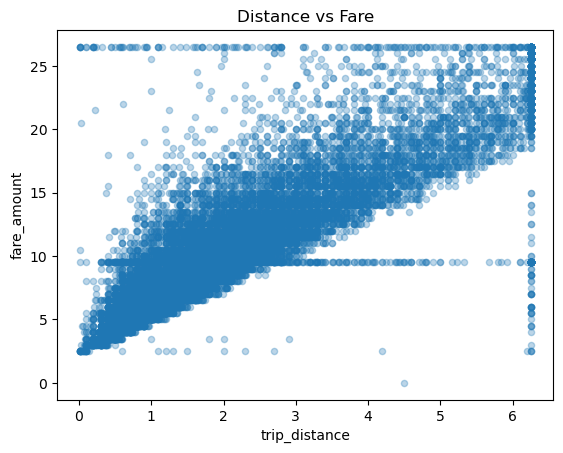

In [26]:
df.plot(kind='scatter', x='trip_distance', y='fare_amount', title='Distance vs Fare',alpha=0.3)

Insight

Longer trip distances generally result in higher fare amounts, showing a positive relationship between distance traveled and taxi fare. However, some variation exists due to additional charges such as tolls, taxes, and surge pricing.

<Axes: title={'center': 'Duration vs Fare'}, xlabel='trip_duration', ylabel='fare_amount'>

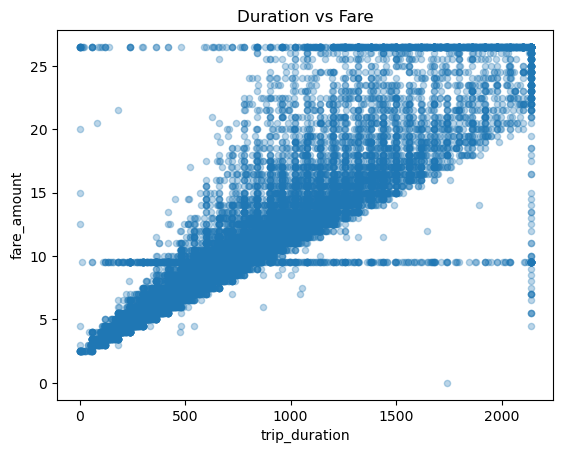

In [27]:
df.plot(kind='scatter', x='trip_duration', y='fare_amount', title='Duration vs Fare',alpha=0.3)

Insight:
Trip duration moderately influences fare, though distance remains the stronger predictor.

<Axes: title={'center': 'Distance vs Total'}, xlabel='trip_distance', ylabel='total_amount'>

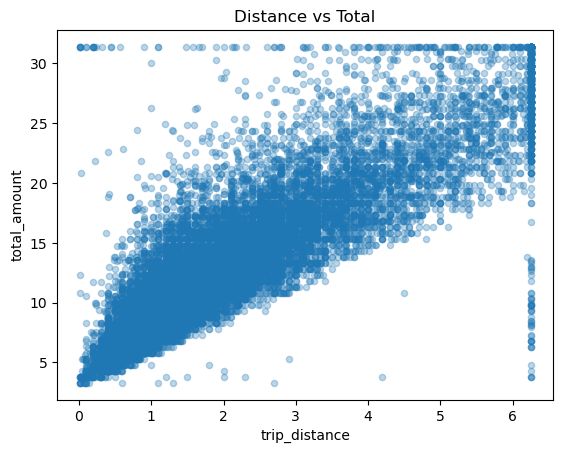

In [28]:
df.plot(kind='scatter', x='trip_distance', y='total_amount', title='Distance vs Total',alpha=0.3)

Insight:
Total amount increases proportionally with distance, including additional charges like tax and tolls.

<Axes: title={'center': 'Boxplot Key Features'}>

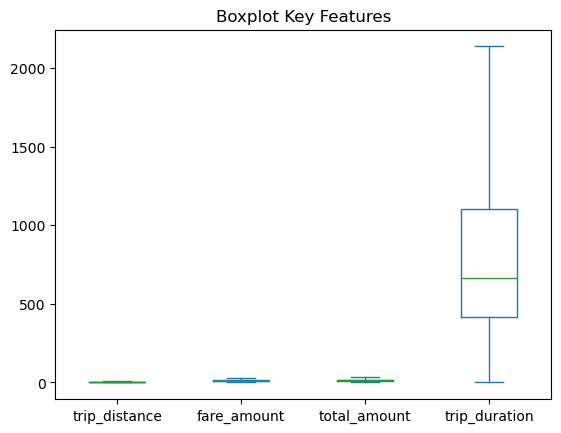

In [29]:
df[['trip_distance','fare_amount','total_amount','trip_duration']].plot(kind='box', title='Boxplot Key Features')

Insight:
All monetary and distance variables show right-skewness and presence of outliers, which is typical in transportation datasets

<Axes: title={'center': 'total_amount'}, xlabel='is_weekend'>

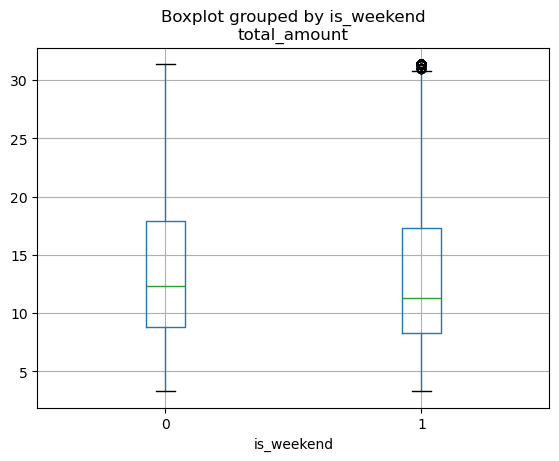

In [30]:
df.boxplot(column='total_amount', by='is_weekend')

Insight:
Weekend trips may show slightly different revenue distribution, possibly due to leisure travel patterns.

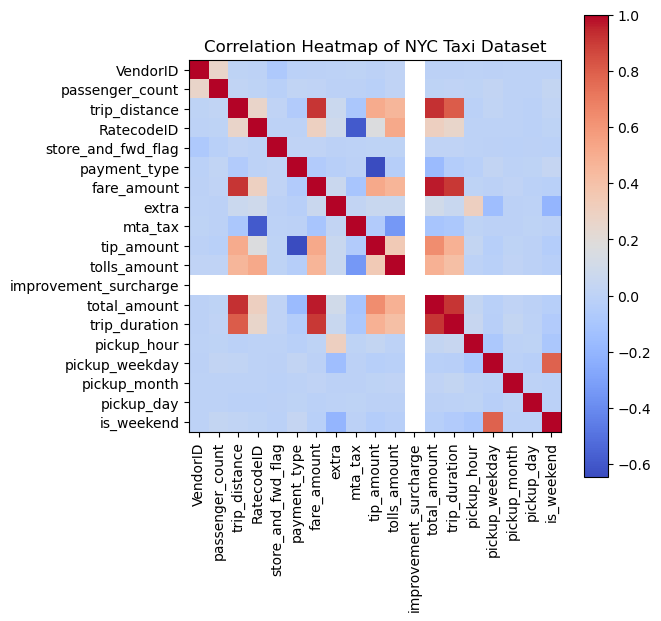

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Select only numerical columns
numeric_cols = df.select_dtypes(include='number')

# Compute correlation matrix
corr = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(6,6))
plt.imshow(corr, cmap='coolwarm', interpolation='none')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap of NYC Taxi Dataset")

plt.show()

Insight:

The correlation heatmap reveals relationships among numerical variables in the dataset. Trip distance shows a strong positive correlation with fare amount and total amount, indicating that longer trips naturally generate higher revenue. Passenger count has very weak correlation with fare, suggesting that taxi pricing primarily depends on trip distance and duration rather than the number of passengers.

<Axes: title={'center': 'Bubble Plot: Distance vs Fare (Passenger Size)'}, xlabel='trip_distance', ylabel='fare_amount'>

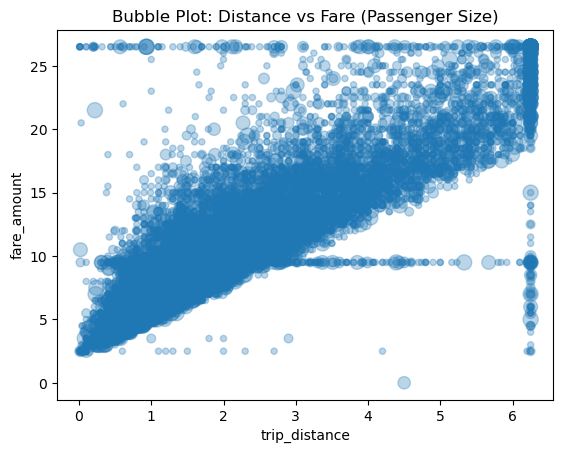

In [32]:
df.plot(
    kind='scatter',
    x='trip_distance',
    y='fare_amount',
    s=df['passenger_count']*20,
    alpha=0.3,
    title='Bubble Plot: Distance vs Fare (Passenger Size)'
)

In [33]:
!pip install folium geopandas

Defaulting to user installation because normal site-packages is not writeable


In [34]:
import sys
!{sys.executable} -m pip install folium geopandas

In [35]:
import folium

In [36]:
import json

with open("nyc_boroughs.geojson") as f:
    borough_geo = json.load(f)

In [37]:
import pandas as pd

df = pd.read_csv("nyc_tlc_cleaned.csv")
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,PU_Borough,DO_Borough,trip_duration,pickup_hour,pickup_weekday,pickup_month,pickup_day,is_weekend
0,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,0,1,13.0,0.0,...,0.3,16.56,Manhattan,Manhattan,844.0,8,5,3,25,1
1,1,2017-04-11 14:53:00,2017-04-11 15:19:00,1,1.80,1,0,1,16.0,0.0,...,0.3,20.80,Manhattan,Manhattan,1560.0,14,1,4,11,0
2,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,0,1,6.5,0.0,...,0.3,8.75,Manhattan,Manhattan,432.0,7,4,12,15,0
3,2,2017-05-07 13:17:00,2017-05-07 13:48:00,1,3.70,1,0,1,20.5,0.0,...,0.3,27.69,Brooklyn,Brooklyn,1860.0,13,6,5,7,1
4,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,0,2,16.5,0.5,...,0.3,17.80,Manhattan,Brooklyn,1003.0,23,5,4,15,1


In [38]:
borough_revenue = (
    df.groupby("PU_Borough")["total_amount"]
      .sum()
      .reset_index()
)

borough_revenue

,PU_Borough,total_amount
0,Bronx,251.960
1,Brooklyn,4938.580
2,EWR,31.375
3,Manhattan,275535.210
4,Queens,37603.105
5,Staten Island,7.300
6,Unknown,4829.265


In [39]:
import folium
import json

with open("nyc_boroughs.geojson") as f:
    borough_geo = json.load(f)

m = folium.Map(location=[40.7128, -74.0060], zoom_start=10)

folium.Choropleth(
    geo_data=borough_geo,
    data=borough_revenue,
    columns=["PU_Borough", "total_amount"],
    key_on="feature.properties.borough", 
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name="Total Taxi Revenue (USD)"
).add_to(m)

m

Insight:
The choropleth map visualizes spatial revenue distribution across NYC boroughs. Darker shades represent higher revenue zones, confirming demand concentration in central urban areas

In [40]:
import sys
!{sys.executable} -m pip install pywaffle

In [41]:
import pywaffle

In [42]:
revenue_share = (
    df.groupby("PU_Borough")["total_amount"]
      .sum()
      .sort_values(ascending=False)
)

revenue_dict = revenue_share.to_dict()

revenue_dict

{'Manhattan': 275535.21,
 'Queens': 37603.105,
 'Brooklyn': 4938.58,
 'Unknown': 4829.265,
 'Bronx': 251.96,
 'EWR': 31.375,
 'Staten Island': 7.3}

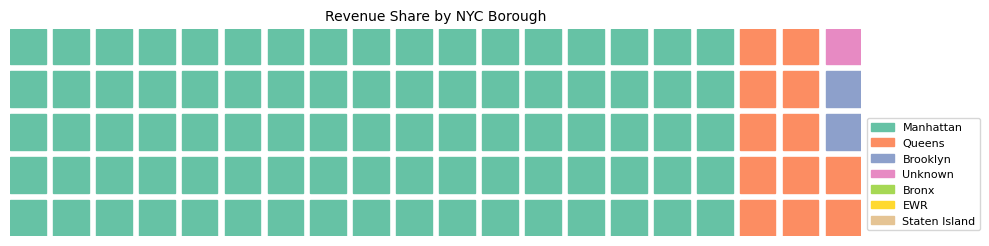

In [43]:
from pywaffle import Waffle
import matplotlib.pyplot as plt

fig = plt.figure(
    FigureClass=Waffle,
    rows=5,                # 5 rows
    columns=20,            # 5x20 = 100 blocks (percentage based)
    values=revenue_dict,
    title={
        'label': 'Revenue Share by NYC Borough',
        'loc': 'center',
        'fontsize': 10
    },
    legend={
        'loc': 'lower left',
        'bbox_to_anchor': (1, 0),
        'fontsize': 8
    },
    figsize=(10, 6)
)

plt.show()

Insight:
The waffle chart clearly shows proportional contribution of each borough to total revenue. Manhattan contributes the highest share, followed by other major boroughs, indicating revenue concentration in commercial hubs.

 Overall Findings

• Taxi demand is highest during commute hours.

• Most trips are short-distance urban rides.

• Revenue is strongly dependent on trip distance.

• Digital payments dominate cash usage.

• Manhattan contributes the largest share of taxi revenue.

• Outliers exist in fare and duration but represent real-world extreme trips.

Categorical Column Descriptions (NYC TLC) VendorID 1 → Creative Mobile Technologies (CMT) 2 → VeriFone Inc.

payment_type 1 → Credit Card 2 → Cash 3 → No Charge 4 → Dispute 5 → Unknown 6 → Voided Trip

RatecodeID 1 → Standard Rate 2 → JFK 3 → Newark 4 → Nassau/Westchester 5 → Negotiated Fare 6 → Group Ride

store_and_fwd_flag 1 → Stored and Forwarded 0→ Sent Directly